# 0. Data Loading and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import alarmist as al

#### adata

For the adata, we assume that:

- You are working with a single AnnData object.

- Cell type annotations are available in adata.obs["cell_type"].

- All cells are annotated with a cell type.

- Raw counts are present in the AnnData object and will be used in Step 6 for downstream analysis.

In [2]:
adata = sc.read_h5ad(
    "/Users/jiayifan/tansey_lab/TMA_punch_subfiles/xenium_mm_final_cell_id.h5ad"
)
results_dir = "../results/GBM_cellchat"
cellchatdb = pd.read_csv("../data/LRdatabase/CellChatDBv2.0.human.csv")

In [3]:
adata = adata[adata.obs["cell_type"].notna()].copy()

In [ ]:
al.set_celltype_colors(adata, column="cell_type", palette="tab20")

In [13]:
results_dir = "/Users/jiayifan/tansey_lab/alarmist/results/SAHA_IBD"

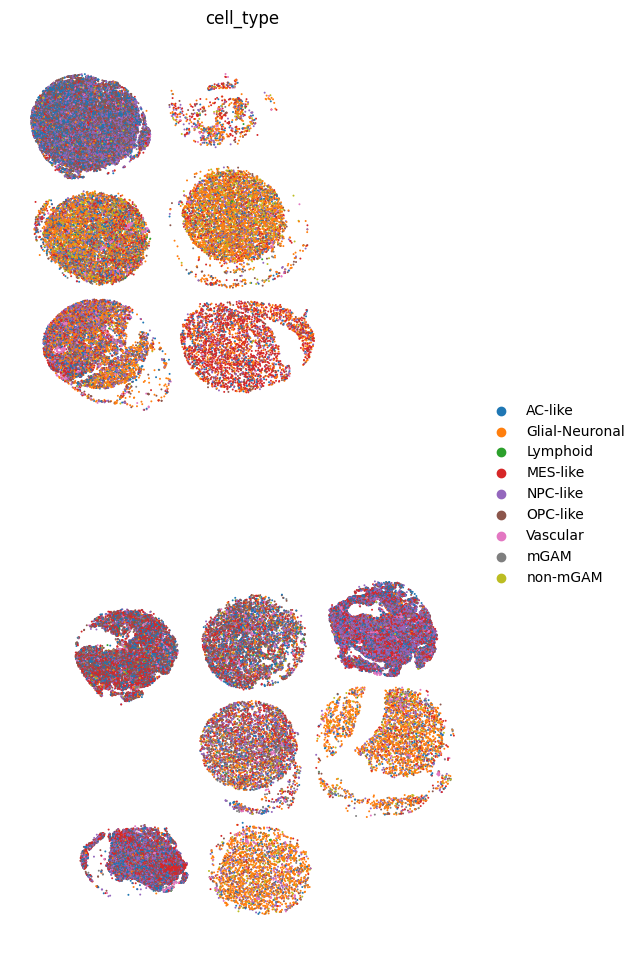

In [ ]:
fig, ax = plt.subplots(figsize=(6, 12))

sc.pl.embedding(
    adata, basis="spatial", color="cell_type", size=8, frameon=False, ax=ax, show=False
)
ax.invert_yaxis()
plt.show()

# 1. Patchify & Count LRI

Note: Make sure your spatial coordinates are in pixels or microns. Here we typically use a patch size of 50–80 µm.

In [ ]:
patch_size = 50.0  # in micrometers

analyzer = al.PatchLRIAnalyzer(
    patch_size=patch_size,
    resource_name="cellchatdb",
    cell_type_column="cell_type",
    cellchatdb_path=cellchatdb,
)

In [ ]:
results = analyzer.run_patchify(
    adata,
    output_dir=results_dir,  # save results in results_dir
)

If the AnnData object contains multiple samples that were concatenated
and share overlapping spatial coordinates, set `multi_sample=True`.
The data will be split by `sample_column` in adata.obs, and patchification will be
performed separately for each sample.

In [ ]:
results = analyzer.run_patchify(
    adata,
    multi_sample=True,
    sample_column="batch",  # or 'tma_id', 'sample_id', etc.
)

Mode 2: Dictionary of AnnData objects (automatic multi-sample mode)
If multiple samples are provided as a dict of {sample_id: AnnData},
ALARMIST will automatically treat each entry as an independent sample
and run patchification separately for each one.

`results = analyzer.run_patchify({
    'sample_A': adata_a,
    'sample_B': adata_b
})`

In [10]:
# Access results
patch_lri_matrix = results["patch_lri_matrix"]

print(f"Matrix shape: {patch_lri_matrix.shape}")
print(f"Number of patches: {patch_lri_matrix.shape[0]}")
print(f"Number of LRI combinations: {patch_lri_matrix.shape[1]}")

Matrix shape: (13113, 65844)
Number of patches: 13113
Number of LRI combinations: 65844


In [ ]:
al.plot_cells_per_patch(adata, save_path=f"{results_dir}/cells_per_patch.png")

# 2. Bayesian Poisson Tensor Factorization

In [ ]:
# results = al.load_patch_lri_results(results_dir) # reload results from results_dir

Loading patch-LRI results from: ../results/GBM_cellchat
Loaded matrix shape: (13113, 65844)
Matrix sparsity: 99.82%


In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Run BPTF
model = al.run_bptf(
    results["patch_lri_matrix"],
    n_components=20,
    max_iter=300,
    verbose=True,
    random_state=42,
)

# Extract factors
patch_loadings, lri_factors = al.extract_factors(model)

print(f"Patch loadings shape: {patch_loadings.shape}")
print(f"LRI factors shape: {lri_factors.shape}")

In [6]:
bptf_results = al.process_bptf_results(model, results, output_dir=f"{results_dir}/bptf")

Rescaling motif matrices...
Reconstruction error: 4.54e-17 (should be ~0)
Creating LRI motifs DataFrame...
Total entries: 509260
Parsing LRI components...
Annotating pathways...
Computing normalized scores...

Saving to ../results/GBM_cellchat/bptf...
../results/GBM_cellchat/bptf/bptf_1.npz
  BPTF model saved
All results saved to: ../results/GBM_cellchat/bptf


# 3. Visualize LRI factors

In [6]:
from alarmist.plotting import (
    plot_celltype_communication_by_motif,
    plot_lri_clustermap,
    plot_lri_factor_scatter,
    plot_lri_networks,
    plot_top_lri_interactions_dot,
)

In [7]:
bptf_results = al.load_bptf_results(f"{results_dir}/bptf")

Loading BPTF results from: ../results/GBM_cellchat/bptf
Loaded results:
  - Patch loadings: (13113, 20)
  - LRI factors: (20, 65844)


In [8]:
lri_motifs = bptf_results["lri_motifs"]

In [7]:
# Get unique cell types from your data
unique_ct = sorted(adata.obs["cell_type"].unique())

In [8]:
lri_motifs

,lri_idx,motif_idx,lri_name,factor,mean,celltype1,celltype2,ligand,receptor,signaling_type,W_max,factor_rescaled,lr_global_mean,factor_lrnorm,score
0,0,0,AC-like|AC-like|TGFB1|TGFBR2_TGFBR1|autocrine,0.000012,0.000305,AC-like,AC-like,TGFB1,TGFBR2_TGFBR1,autocrine,0.017881,2.089844e-07,0.066423,0.000011,1.959677e-07
1,0,1,AC-like|AC-like|TGFB1|TGFBR2_TGFBR1|autocrine,0.000006,0.000305,AC-like,AC-like,TGFB1,TGFBR2_TGFBR1,autocrine,0.021311,1.322005e-07,0.066423,0.000006,1.239663e-07
2,0,2,AC-like|AC-like|TGFB1|TGFBR2_TGFBR1|autocrine,0.000011,0.000305,AC-like,AC-like,TGFB1,TGFBR2_TGFBR1,autocrine,0.046369,5.276867e-07,0.066423,0.000011,4.948195e-07
3,0,3,AC-like|AC-like|TGFB1|TGFBR2_TGFBR1|autocrine,0.000007,0.000305,AC-like,AC-like,TGFB1,TGFBR2_TGFBR1,autocrine,0.039989,2.665964e-07,0.066423,0.000006,2.499913e-07
4,0,4,AC-like|AC-like|TGFB1|TGFBR2_TGFBR1|autocrine,0.000009,0.000305,AC-like,AC-like,TGFB1,TGFBR2_TGFBR1,autocrine,0.072907,6.436148e-07,0.066423,0.000008,6.035270e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509255,65833,15,mGAM|mGAM|VCAM1|ITGAD_ITGB2|juxtacrine,0.000008,0.002822,mGAM,mGAM,VCAM1,ITGAD_ITGB2,juxtacrine,0.031796,2.575717e-07,0.005720,0.000008,2.561069e-07
509256,65833,16,mGAM|mGAM|VCAM1|ITGAD_ITGB2|juxtacrine,0.000077,0.002822,mGAM,mGAM,VCAM1,ITGAD_ITGB2,juxtacrine,0.004206,3.247389e-07,0.005720,0.000077,3.228921e-07
509257,65833,17,mGAM|mGAM|VCAM1|ITGAD_ITGB2|juxtacrine,0.000005,0.002822,mGAM,mGAM,VCAM1,ITGAD_ITGB2,juxtacrine,0.033140,1.576365e-07,0.005720,0.000005,1.567400e-07
509258,65833,18,mGAM|mGAM|VCAM1|ITGAD_ITGB2|juxtacrine,0.000005,0.002822,mGAM,mGAM,VCAM1,ITGAD_ITGB2,juxtacrine,0.033974,1.667769e-07,0.005720,0.000005,1.658284e-07


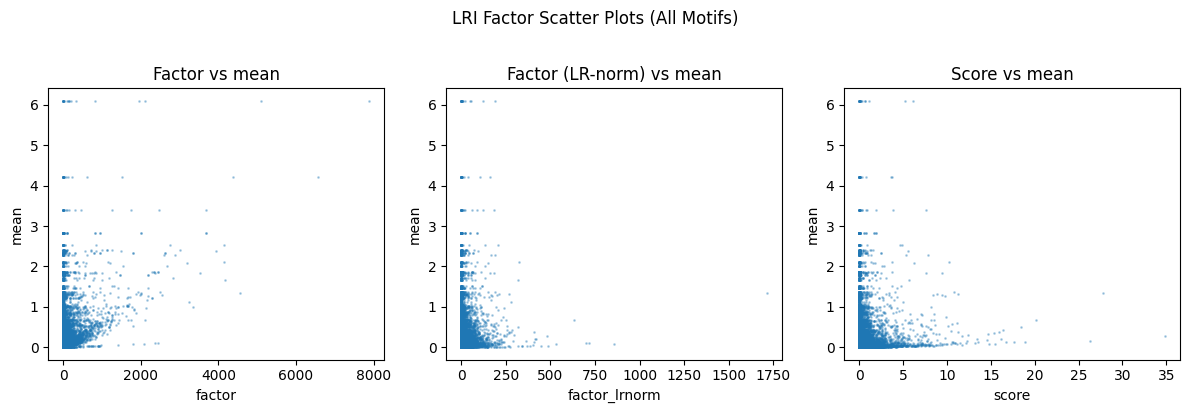

In [9]:
fig = plot_lri_factor_scatter(lri_motifs)

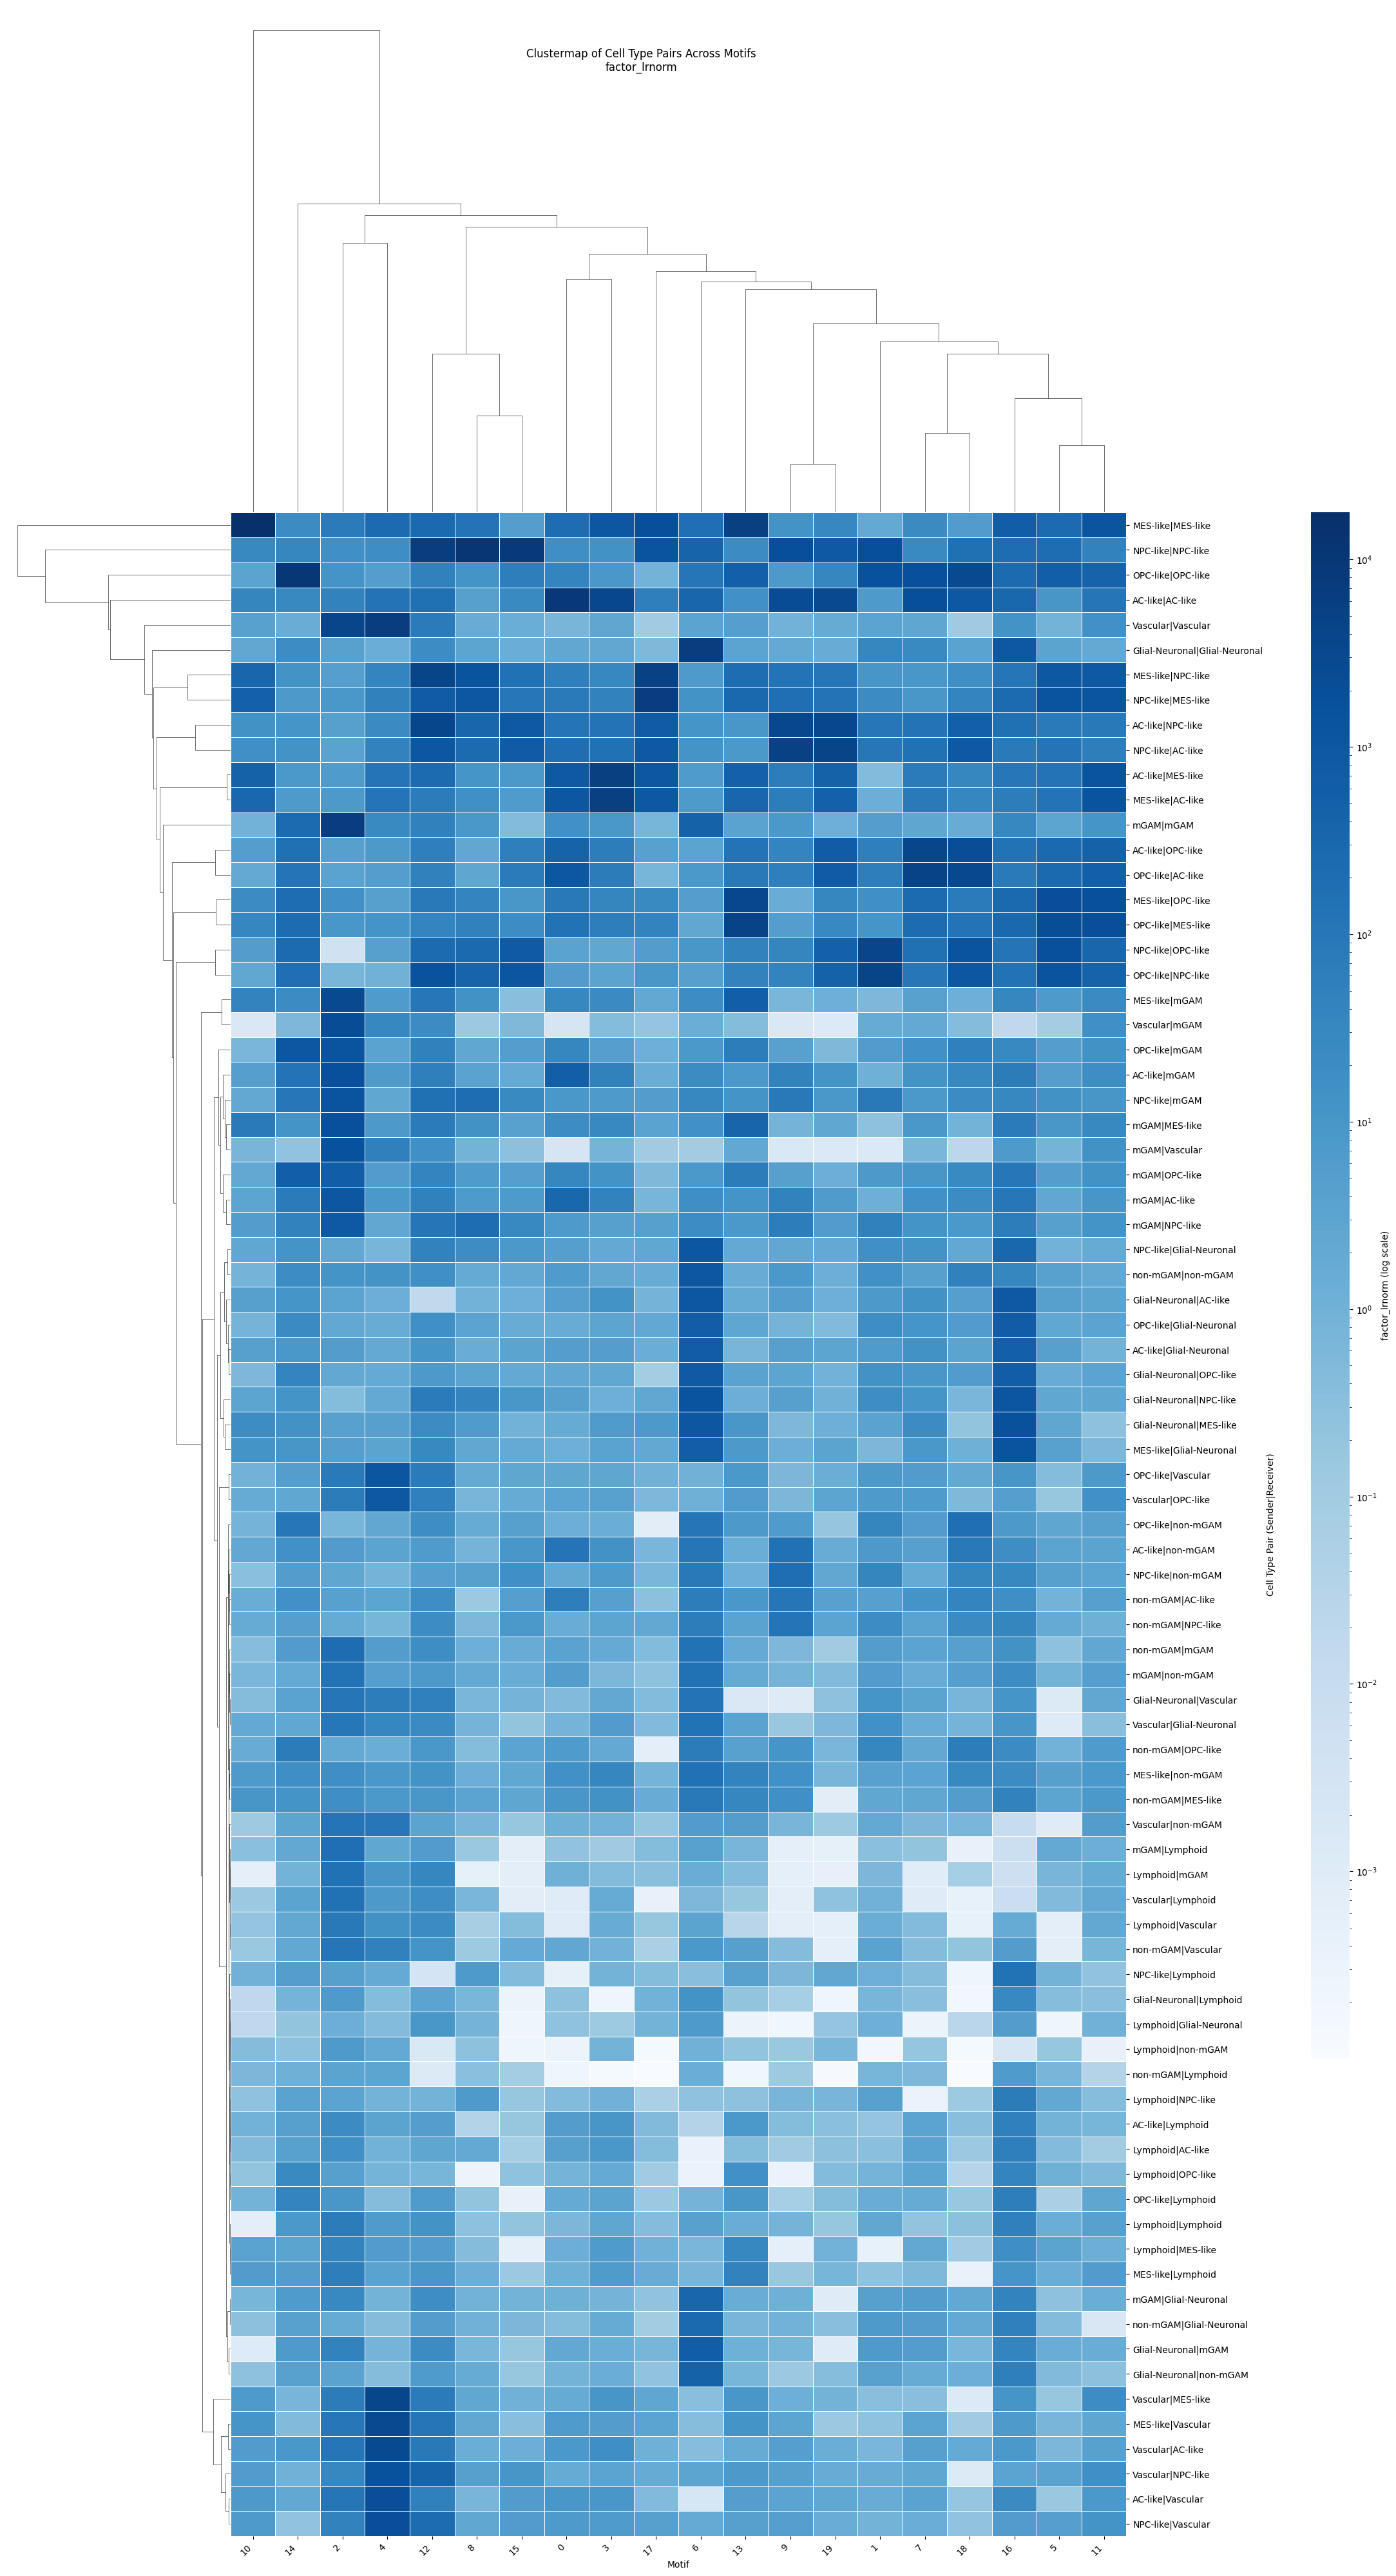

In [ ]:
fig = plot_lri_clustermap(
    lri_motifs,
    factor_col="factor_lrnorm",
    #   save_path=f'{results_dir}/bptf_plots_20/lri_clustermap_factor_lrnorm.svg'
)

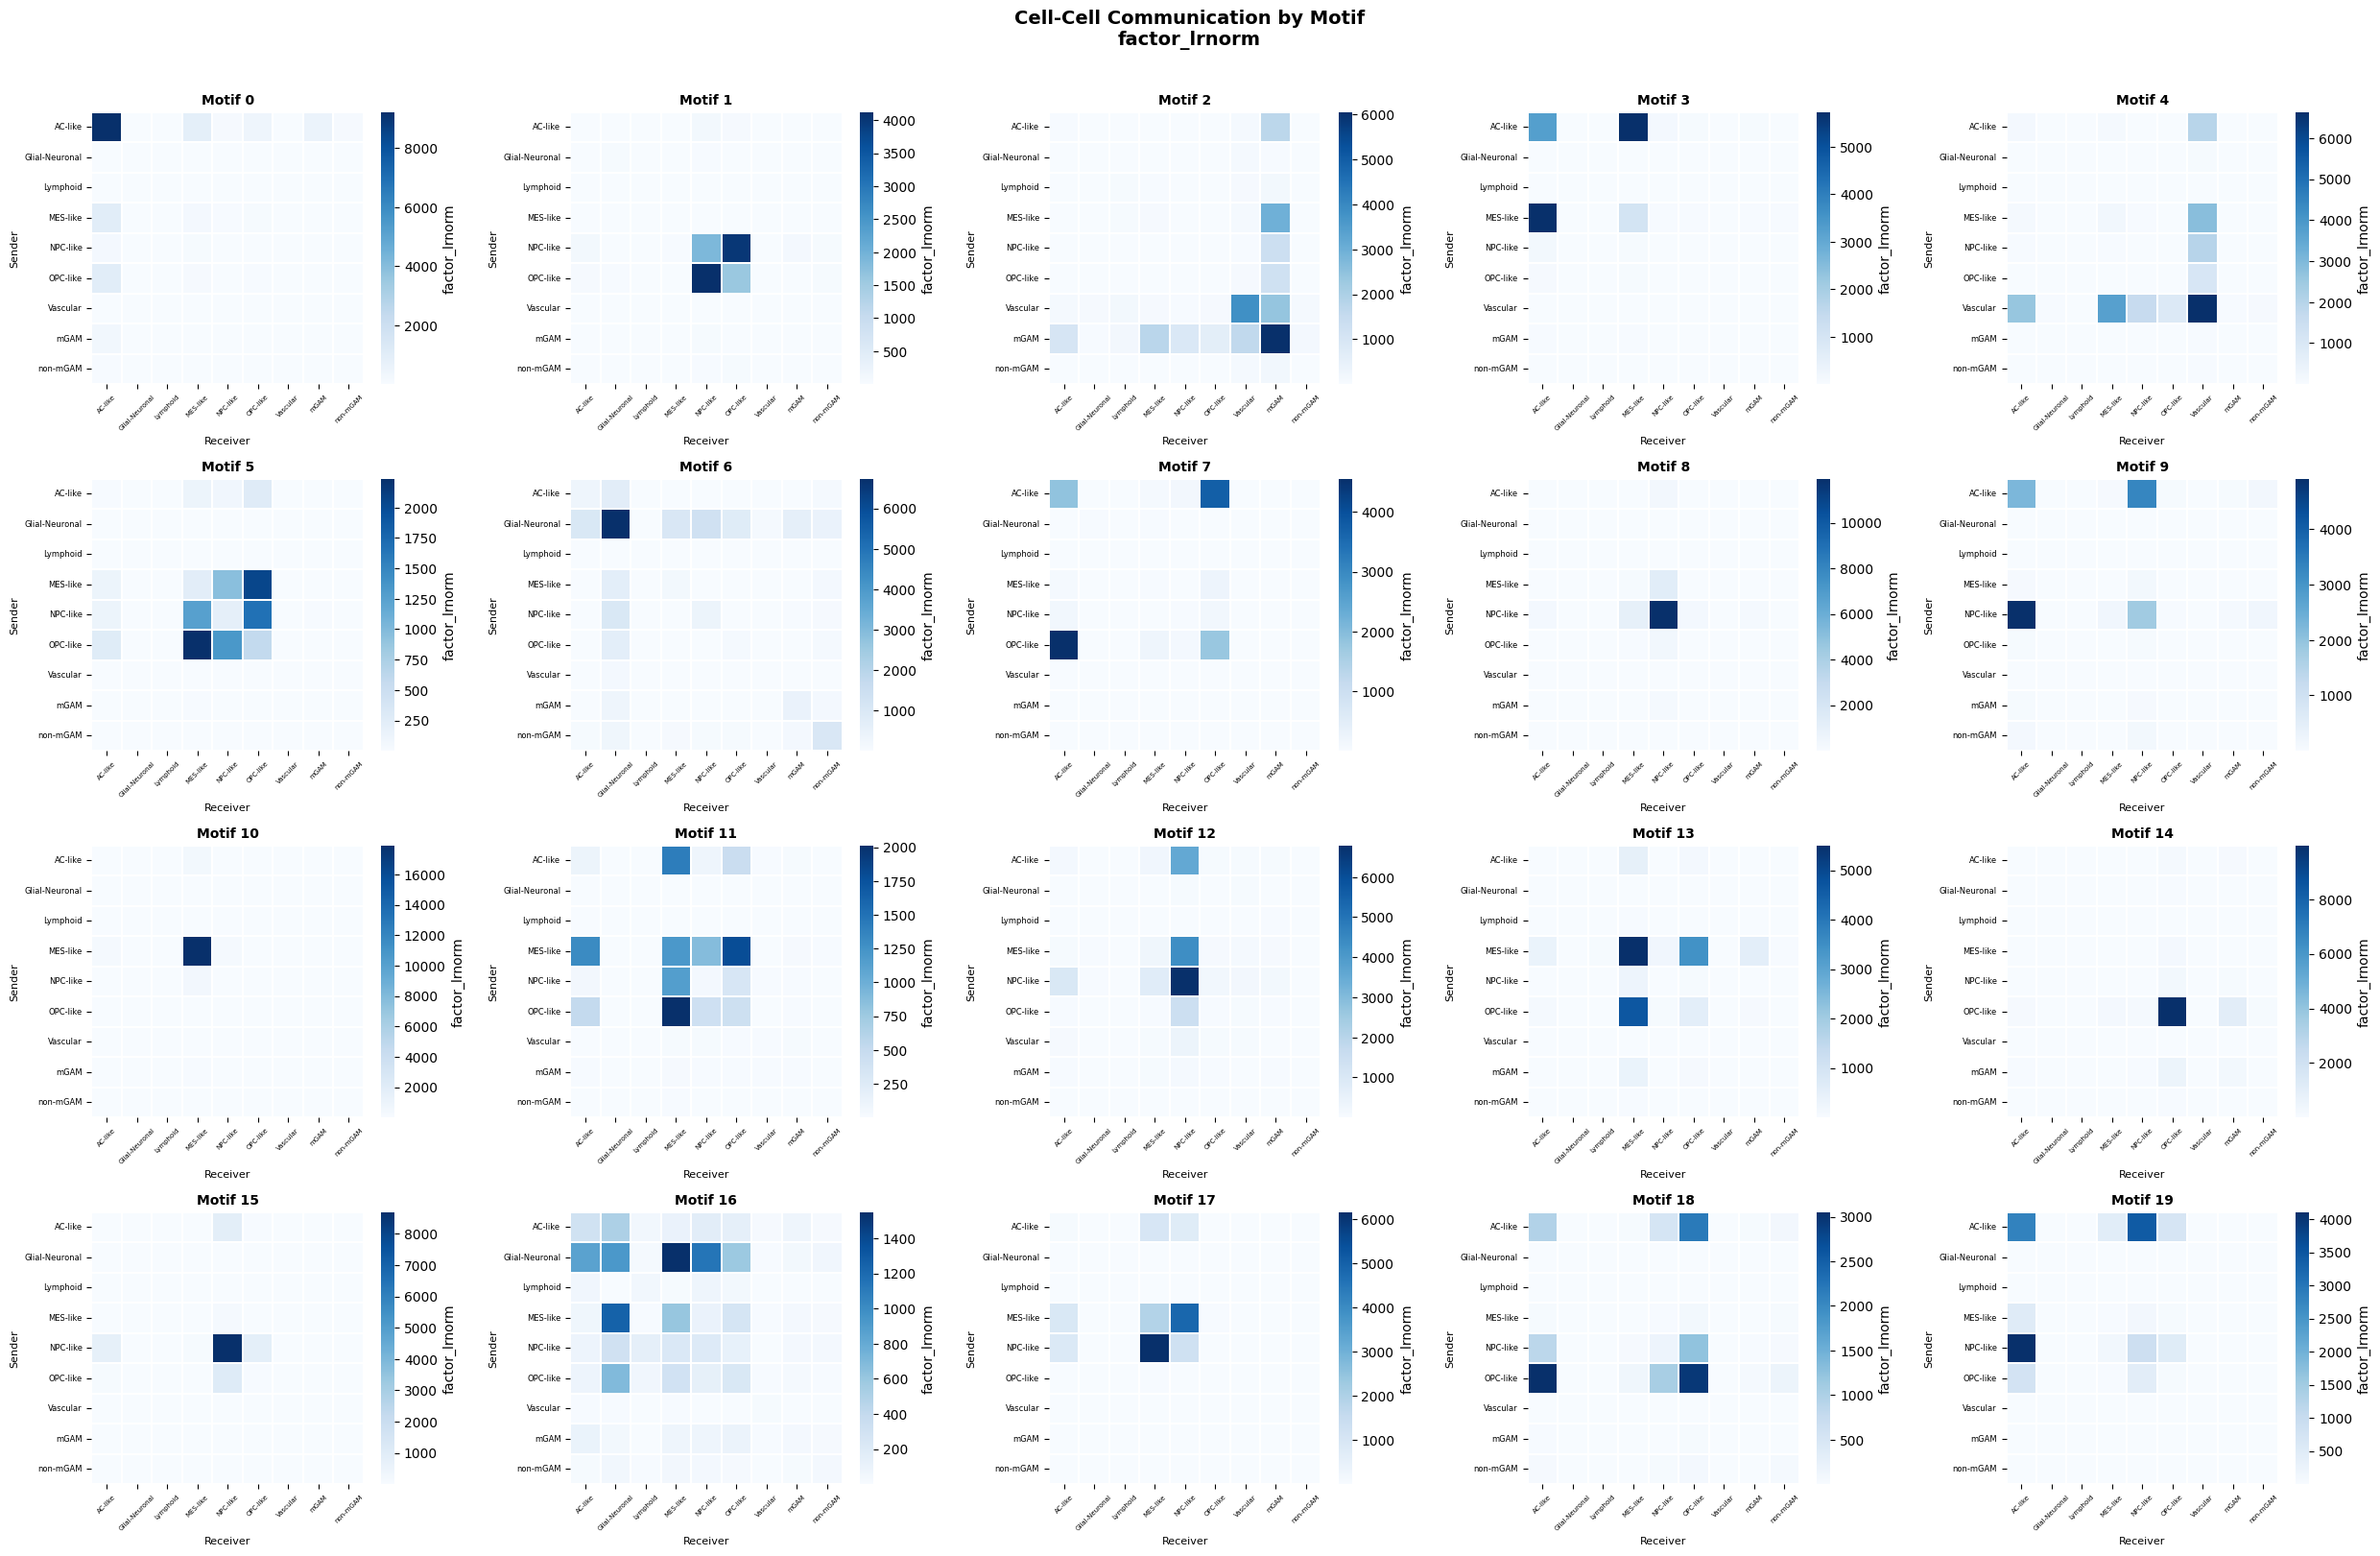

In [12]:
fig = plot_celltype_communication_by_motif(
    lri_motifs,
    factor_col="factor_lrnorm",
    n_cols=5,
    #   save_path=f'{results_dir}/bptf_plots_20/celltype_communication_factor_lrnorm.pdf'
)

3. Plotting top LRI interactions...
Saved: ../results/GBM_cellchat/bptf_plots_20/top_lri_interactions_factor_lrnorm.pdf


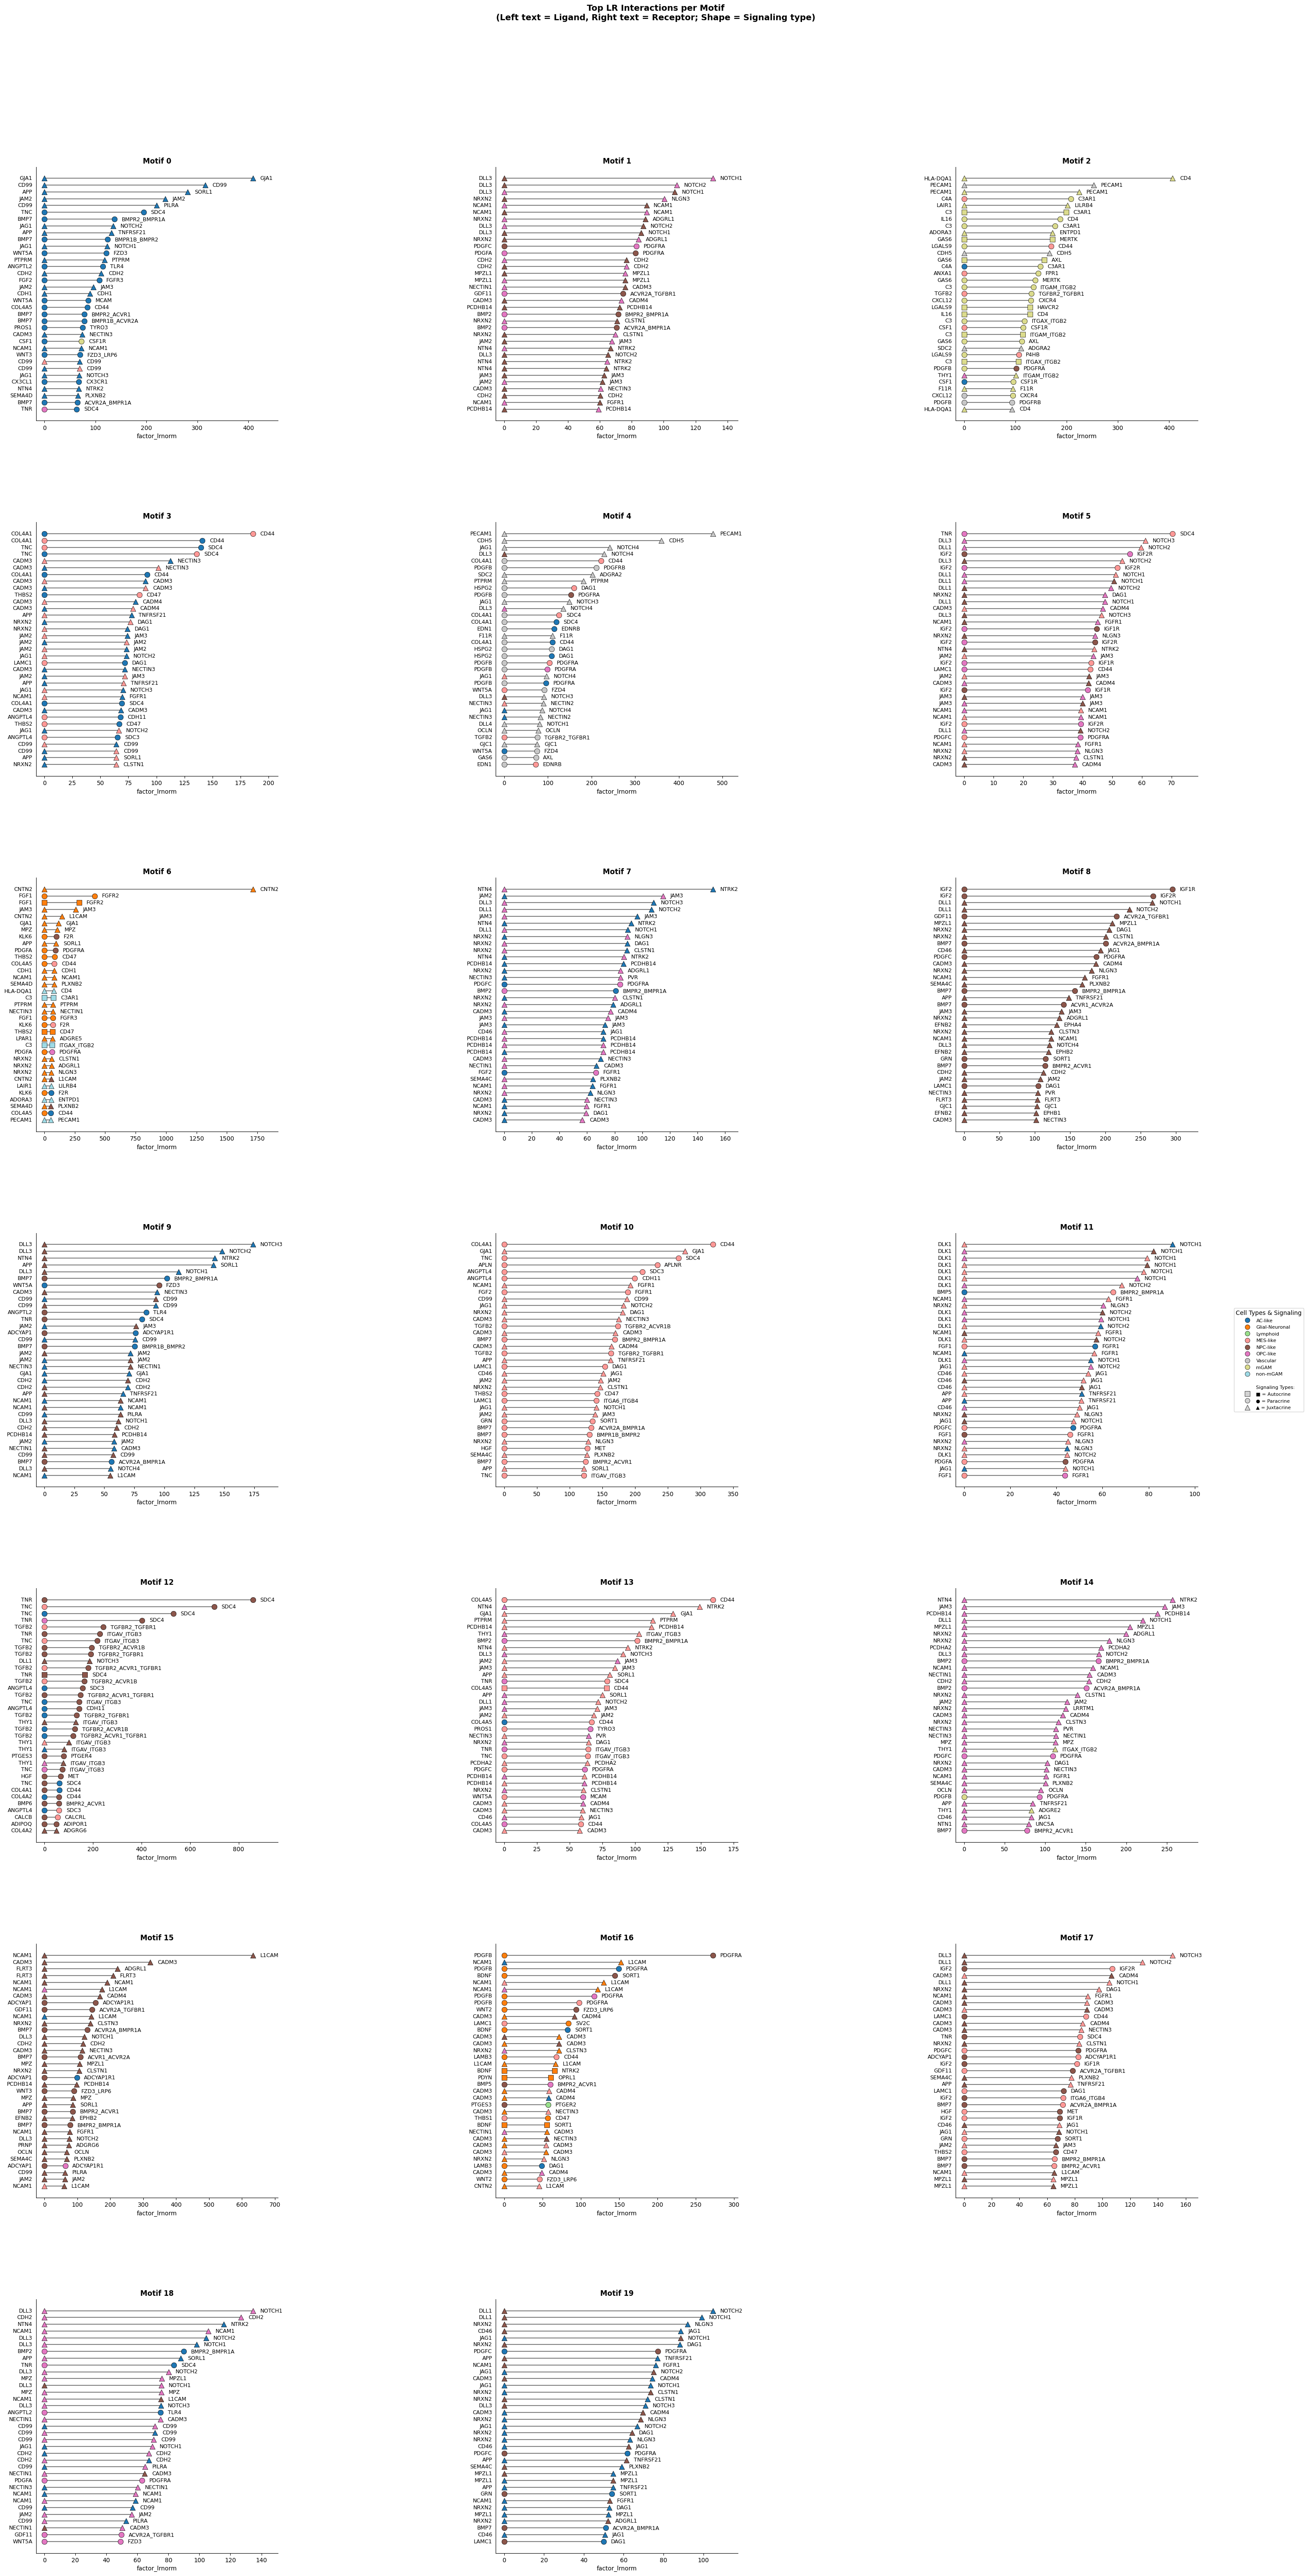

In [ ]:
# 2.3 Top LRI interactions (dot plot - RECOMMENDED)
print("3. Plotting top LRI interactions...")
fig = plot_top_lri_interactions_dot(
    lri_motifs,
    factor_col="factor_lrnorm",
    top_n=35,
    save_path=f"{results_dir}/bptf_plots_20/top_lri_interactions_factor_lrnorm.pdf",
)

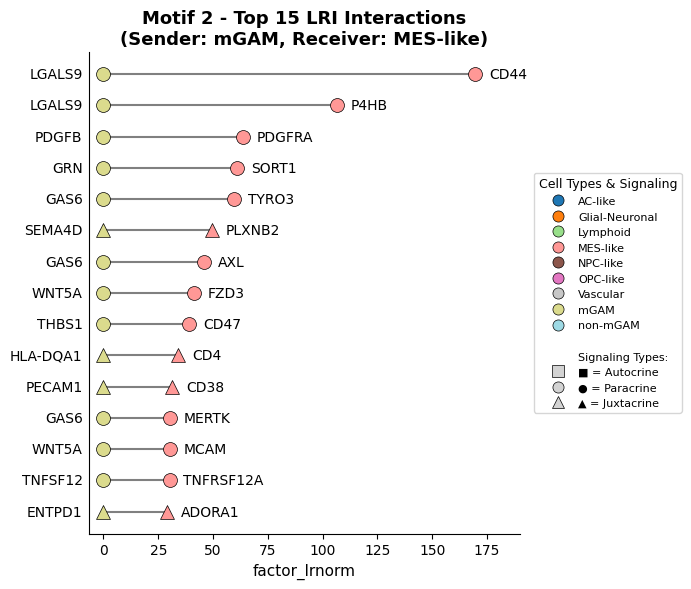

In [10]:
fig = al.plotting.plot_single_motif_lri_lollipop(
    lri_motifs,
    motif_idx=2,
    sender_type="mGAM",
    receiver_type="MES-like",
    factor_col="factor_lrnorm",
    top_n=15,
    figsize=(7, 6),
    #   save_path=f'{results_dir}/bptf_plots_20/motif_2_mGAM_sender_lollipop.svg'
)

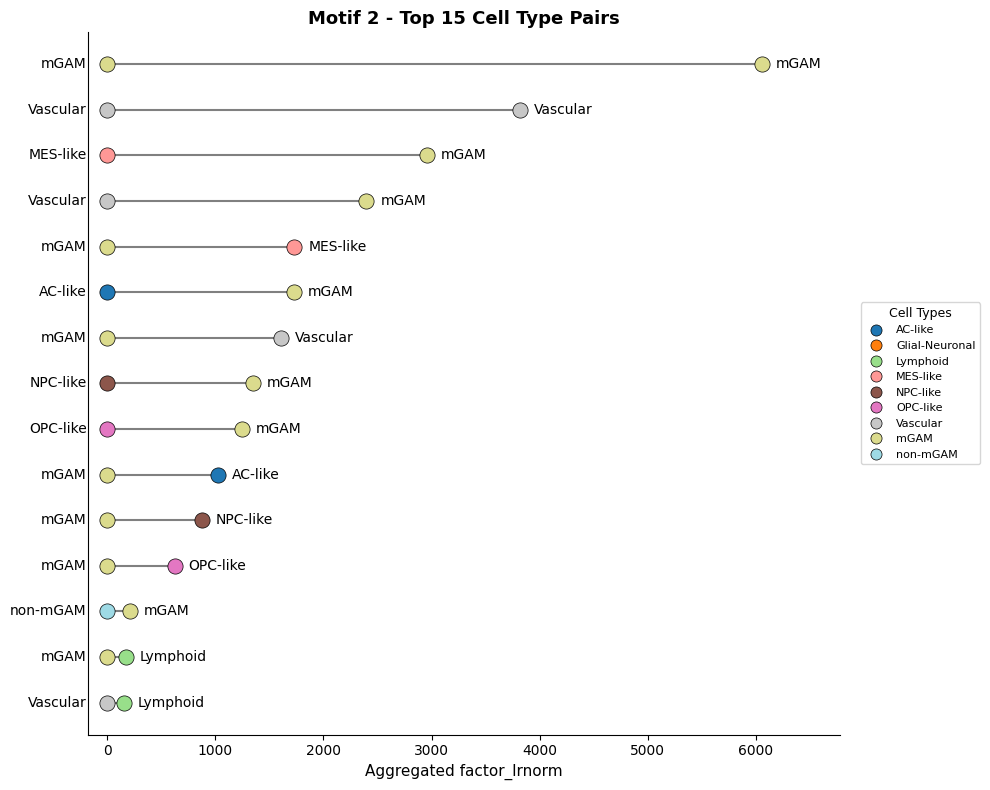

In [9]:
fig = al.plotting.plot_single_motif_cellpair_lollipop(
    lri_motifs,
    motif_idx=2,
    factor_col="factor_lrnorm",  # 或 'factor_norm', 'factor_lrnorm' 等
    top_n=15,
)

5. Creating network graphs...


Saved: ../results/GBM_cellchat/bptf_plots_20/networks_factor_lrnorm.png


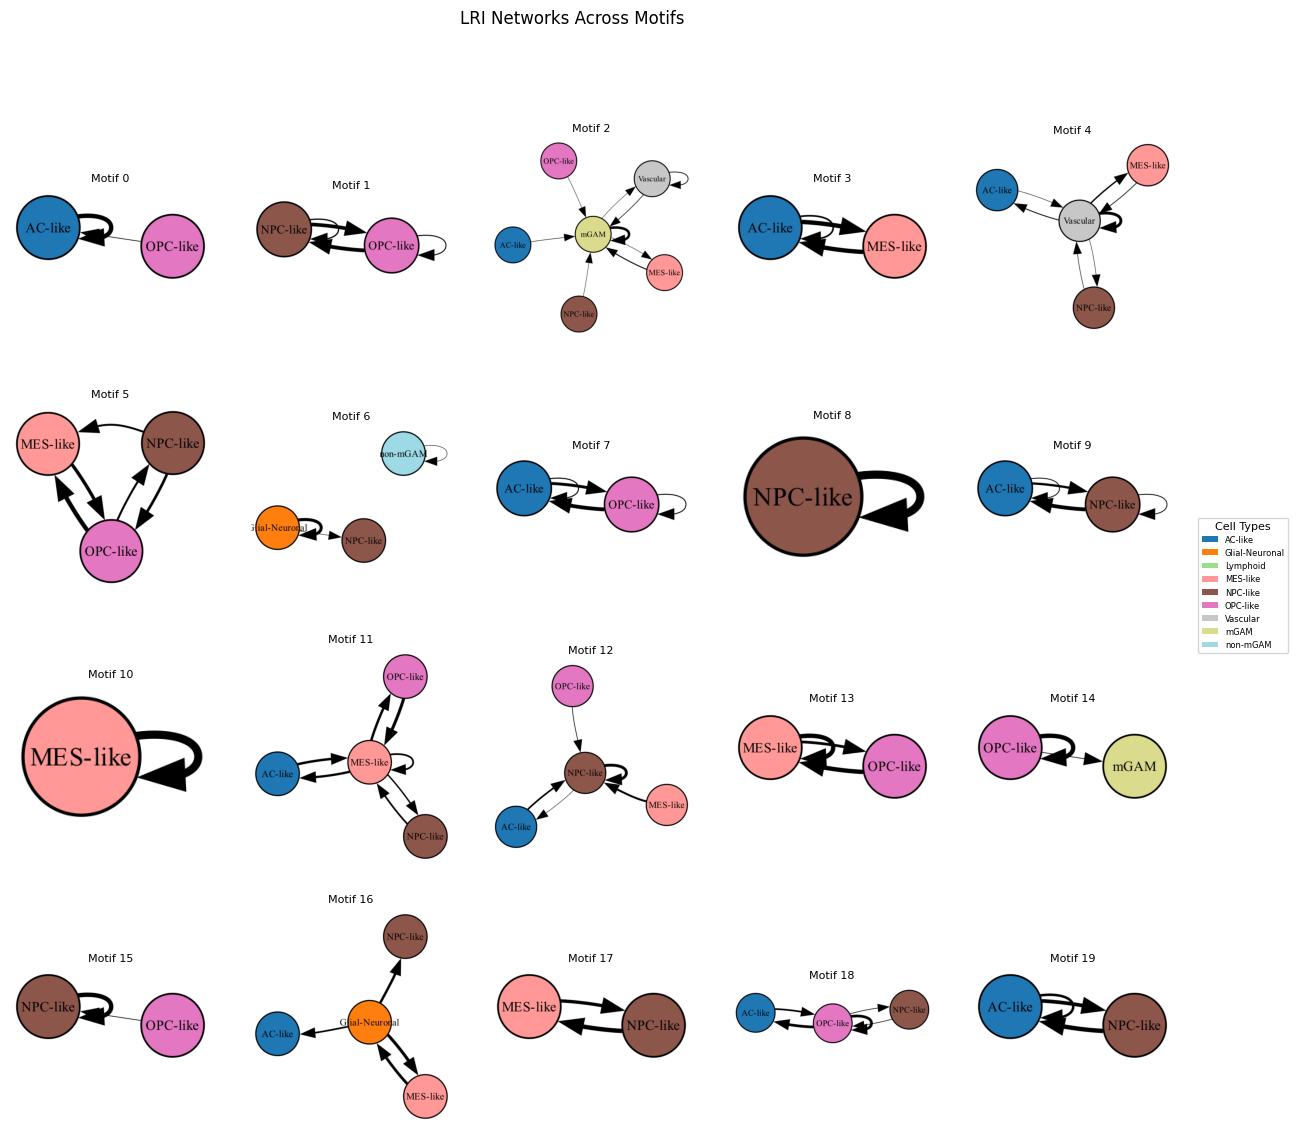

In [ ]:
# 2.5 Network graphs (requires Graphviz)
print("5. Creating network graphs...")

fig = plot_lri_networks(
    lri_motifs,
    top_n=200,
    threshold=500,
    mode_filter=None,
    factor_col="factor_lrnorm",
    save_path=f"{results_dir}/bptf_plots_20/networks_factor_lrnorm.png",
)

# 4. Single Cell Projection

In [3]:
results = al.load_patch_lri_results(results_dir)  # reload results from results_dir

Loading patch-LRI results from: ../results/GBM_cellchat
Loaded matrix shape: (13113, 65844)
Matrix sparsity: 99.82%


In [ ]:
cell_analyzer = al.NeighborhoodLRIAnalyzer(
    neighborhood_size=patch_size, resource_name="cellchatdb", cellchatdb_path=cellchatdb
)

cell_results = cell_analyzer.run_neighborhood(
    adata,
    output_dir=f"{results_dir}/single_cell",
    required_columns=results["column_names"],
)

In [ ]:
# if multiple samples
cell_results = cell_analyzer.run_neighborhood(
    adata,
    output_dir=f"{results_dir}/single_cell",
    required_columns=results["column_names"],
    multi_sample=True,
    sample_column="batch",
)

In [ ]:
cell_results = al.load_cell_lri_results(f"{results_dir}/single_cell_20")
cell_results.keys()

Loading cell-LRI results from: ../results/GBM_cellchat/single_cell_20
Loaded matrix shape: (100197, 70963)
Matrix sparsity: 99.07%


dict_keys(['cell_lri_matrix', 'column_names', 'parameters'])

In [6]:
from pathlib import Path

from bptf import load_bptf

model = load_bptf(Path(f"{results_dir}/bptf/bptf_1.npz"))

In [ ]:
np.random.seed(42)

cell_loadings = al.project_cell_loadings(
    model=model,
    cell_lri_matrix=cell_results["cell_lri_matrix"],
    max_iter=200,
    chunk_size=5000,
    verbose=True,
    output_dir=f"{results_dir}/single_cell",
)

# 5. Visualize Cell Loadings

In [10]:
from alarmist.plotting import plot_motif_spatial

In [5]:
cell_loadings = np.load(f"{results_dir}/single_cell_20/cell_loadings.npy")

Analyzing cell type composition per motif...
  Mode: Single sample
  Cells: 100,197
  Motifs: 20


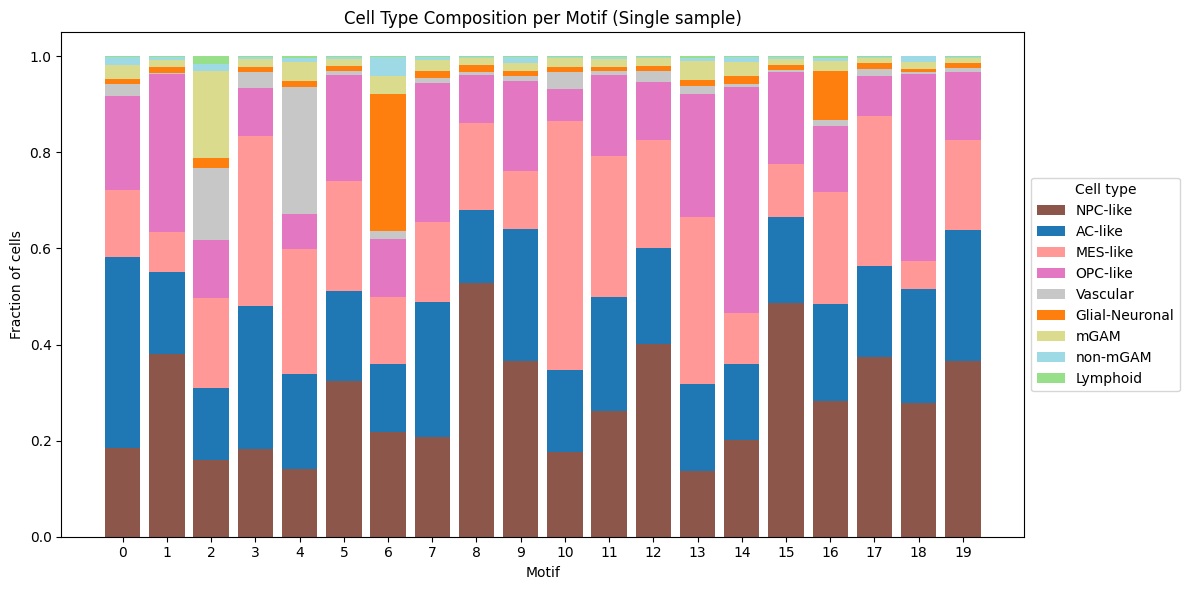

In [6]:
fig, ax, tidy_df = al.analyze_motif_celltype_composition(
    adata,  # or adata_dict or adata_merged + sample_column
    cell_loadings,
    cell_type_column="cell_type",
    # output_dir=f'{results_dir}/single_cell'  # optional
)

In [7]:
gmm_summary = al.gmm_binarize_all_motifs(cell_loadings, adata)

In [ ]:
# if multiple samples
gmm_summary = al.gmm_binarize_all_motifs(
    cell_loadings, adata, multi_sample=True, sample_column="patient_id"
)

Computing ON/OFF statistics...
  Mode: Single sample
  Cells: 100,197
  Motifs: 20


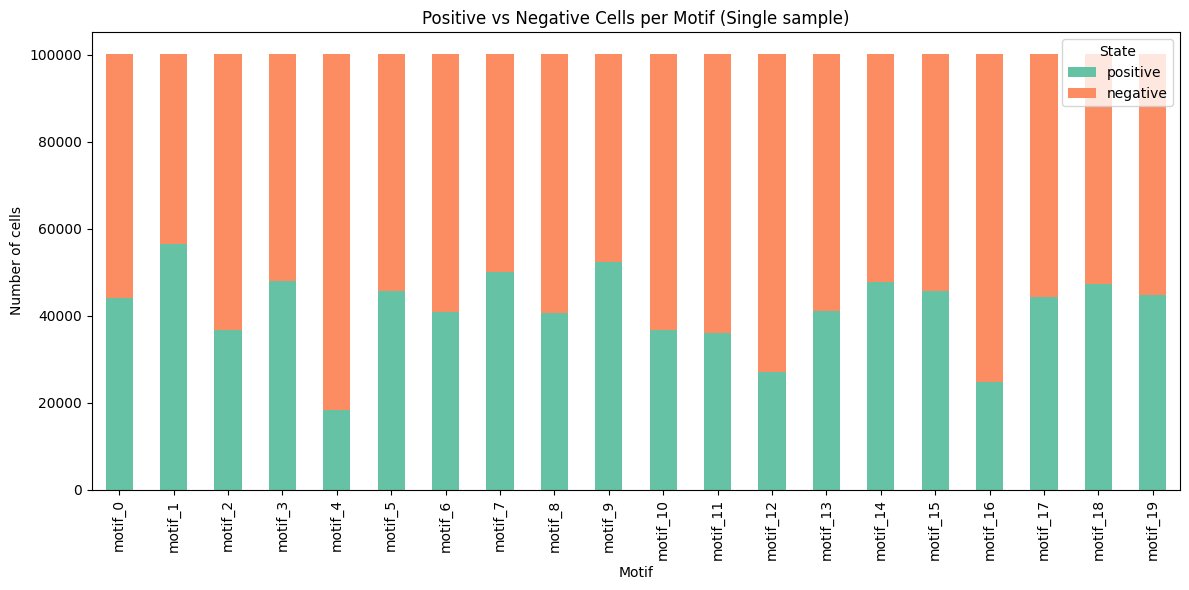

In [8]:
fig, ax, counts_df = al.analyze_motif_state_counts(
    adata,
    # output_dir=f'{results_dir}/single_cell'
)

In [14]:
adata

AnnData object with n_obs × n_vars = 100197 × 5119
    obs: 'nucleus_label', 'nucleus_centroid_x', 'nucleus_centroid_y', 'area', 'centroid_x', 'centroid_y', 'tma_id', 'old_cell_type', 'merged_conf_score', 'cell_type', 'MES_score', 'AC_score', 'subtype', 'OPC_score', 'NPC_score', 'MES-like', 'AC-like', 'OPC-like', 'NPC-like', 'z-score MES-like', 'q MES-like', 'z-score AC-like', 'q AC-like', 'z-score OPC-like', 'q OPC-like', 'z-score NPC-like', 'q NPC-like', 'patch_id', 'motif', 'grade', 'cell_id', 'motif_0_loading', 'motif_0_state', 'motif_1_loading', 'motif_1_state', 'motif_2_loading', 'motif_2_state', 'motif_3_loading', 'motif_3_state', 'motif_4_loading', 'motif_4_state', 'motif_5_loading', 'motif_5_state', 'motif_6_loading', 'motif_6_state', 'motif_7_loading', 'motif_7_state', 'motif_8_loading', 'motif_8_state', 'motif_9_loading', 'motif_9_state', 'motif_10_loading', 'motif_10_state', 'motif_11_loading', 'motif_11_state', 'motif_12_loading', 'motif_12_state', 'motif_13_loading', 'mot

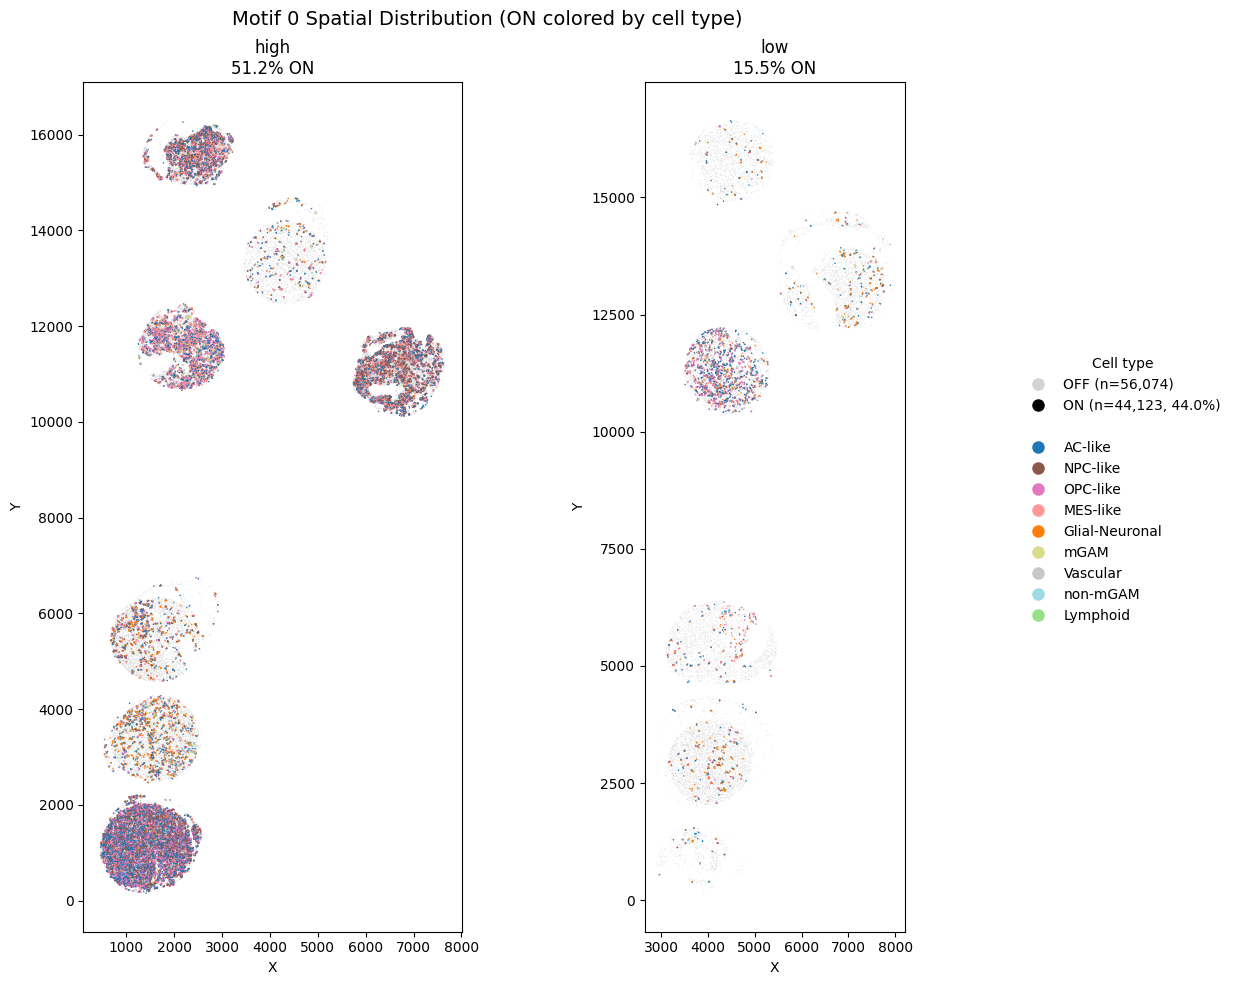

In [ ]:
# single sample, single motif
fig = plot_motif_spatial(
    adata,
    motif_idx=0,
    n_cols=2,
    point_size=0.2,
    sample_column="grade",
    figsize_per_panel=(4, 10),
    #  output_dir=f'{results_dir}/spatial'
)

In [ ]:
figs = plot_motif_spatial(
    adata,
    motif_idx=range(20),
    color_by_celltype=True,
    output_dir=f"{results_dir}/spatial",
    n_cols=2,
    point_size=0.2,
    sample_column="grade",
    figsize_per_panel=(4, 10),
)

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu


def plot_motif_fraction_by_grade(
    adata,
    motif_idx: int | list[int],
    group_col: str = "tma_id",
    grade_col: str = "grade",
    grade_order: list = ["low", "high"],
    n_cols: int = 4,
    figsize_per_panel: tuple = (4, 4),
    palette: str = "Set2",
    save_path: str | None = None,
) -> tuple[plt.Figure, np.ndarray, pd.DataFrame, dict]:
    """
    Compare motif positive cell fraction between grades with boxplot and Mann-Whitney test.

    Parameters
    ----------
    adata : AnnData
        Must contain motif_{k}_state in obs
    motif_idx : int or list of int
        Motif index(es) to analyze. If list, creates grid of subplots.
    group_col : str
        Column to group cells by (e.g., 'tma_id', 'sample_id')
    grade_col : str
        Column containing grade labels (e.g., 'high', 'low')
    grade_order : list
        Order of grades on x-axis
    n_cols : int
        Number of columns in subplot grid (when motif_idx is list)
    figsize_per_panel : tuple
        Figure size per panel
    palette : str
        Seaborn color palette
    save_path : str, optional
        Path to save figure (supports svg, pdf, png)

    Returns
    -------
    fig : Figure
    axes : array of Axes
    summary_df : DataFrame with motif fraction per group (all motifs)
    p_values : dict mapping motif_idx -> p-value
    """
    # Handle single motif
    if isinstance(motif_idx, int):
        motif_idx = [motif_idx]

    n_motifs = len(motif_idx)
    n_cols = min(n_cols, n_motifs)
    n_rows = (n_motifs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    df = adata.obs.copy()
    all_summaries = []
    p_values = {}

    for i, k in enumerate(motif_idx):
        ax = axes_flat[i]
        state_col = f"motif_{k}_state"

        if state_col not in df.columns:
            ax.set_title(f"Motif {k}\n(no data)")
            ax.axis("off")
            continue

        # Compute fraction per group
        df["_motif_pos"] = (df[state_col] == "positive").astype(int)

        summary = (
            df.groupby(group_col)
            .agg(
                motif_count=("_motif_pos", "sum"),
                total_cells=("_motif_pos", "size"),
                grade=(grade_col, "first"),
            )
            .reset_index()
        )
        summary["motif_fraction"] = summary["motif_count"] / summary["total_cells"]
        summary["motif_idx"] = k
        all_summaries.append(summary)

        # Statistical test
        groups = [
            summary.loc[summary["grade"] == g, "motif_fraction"] for g in grade_order
        ]
        if len(groups[0]) > 0 and len(groups[1]) > 0:
            u, p = mannwhitneyu(groups[1], groups[0], alternative="two-sided")
        else:
            p = np.nan
        p_values[k] = p

        # Plot
        sns.boxplot(
            data=summary,
            x="grade",
            y="motif_fraction",
            order=grade_order,
            palette=palette,
            width=0.5,
            fliersize=0,
            ax=ax,
        )
        sns.stripplot(
            data=summary,
            x="grade",
            y="motif_fraction",
            order=grade_order,
            color="black",
            alpha=0.6,
            size=3,
            ax=ax,
        )

        ax.set_title(f"Motif {k}")
        ax.set_xlabel("")
        ax.set_ylabel("Positive Fraction" if i % n_cols == 0 else "")

        # Annotate p-value
        ymax = summary["motif_fraction"].max()
        h = 0.05 * max(ymax, 0.01)
        y = ymax * 1.05
        x1, x2 = 0, 1

        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1, c="k")
        p_str = f"p={p:.1e}" if p < 0.001 else f"p={p:.3f}"
        ax.text(
            (x1 + x2) / 2, y + h * 1.05, p_str, ha="center", va="bottom", fontsize=8
        )
        ax.set_ylim(top=y + h * 2.5)

    # Hide unused axes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis("off")

    # Combined summary
    summary_df = (
        pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()
    )

    plt.suptitle(
        f"Motif Positive Fraction ({grade_order[1].title()} vs {grade_order[0].title()})",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_path}")

    return fig, axes, summary_df, p_values

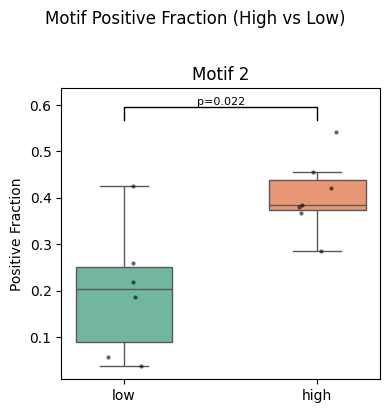

In [19]:
# 单个 motif
fig, axes, summary, p_values = plot_motif_fraction_by_grade(adata, motif_idx=2)

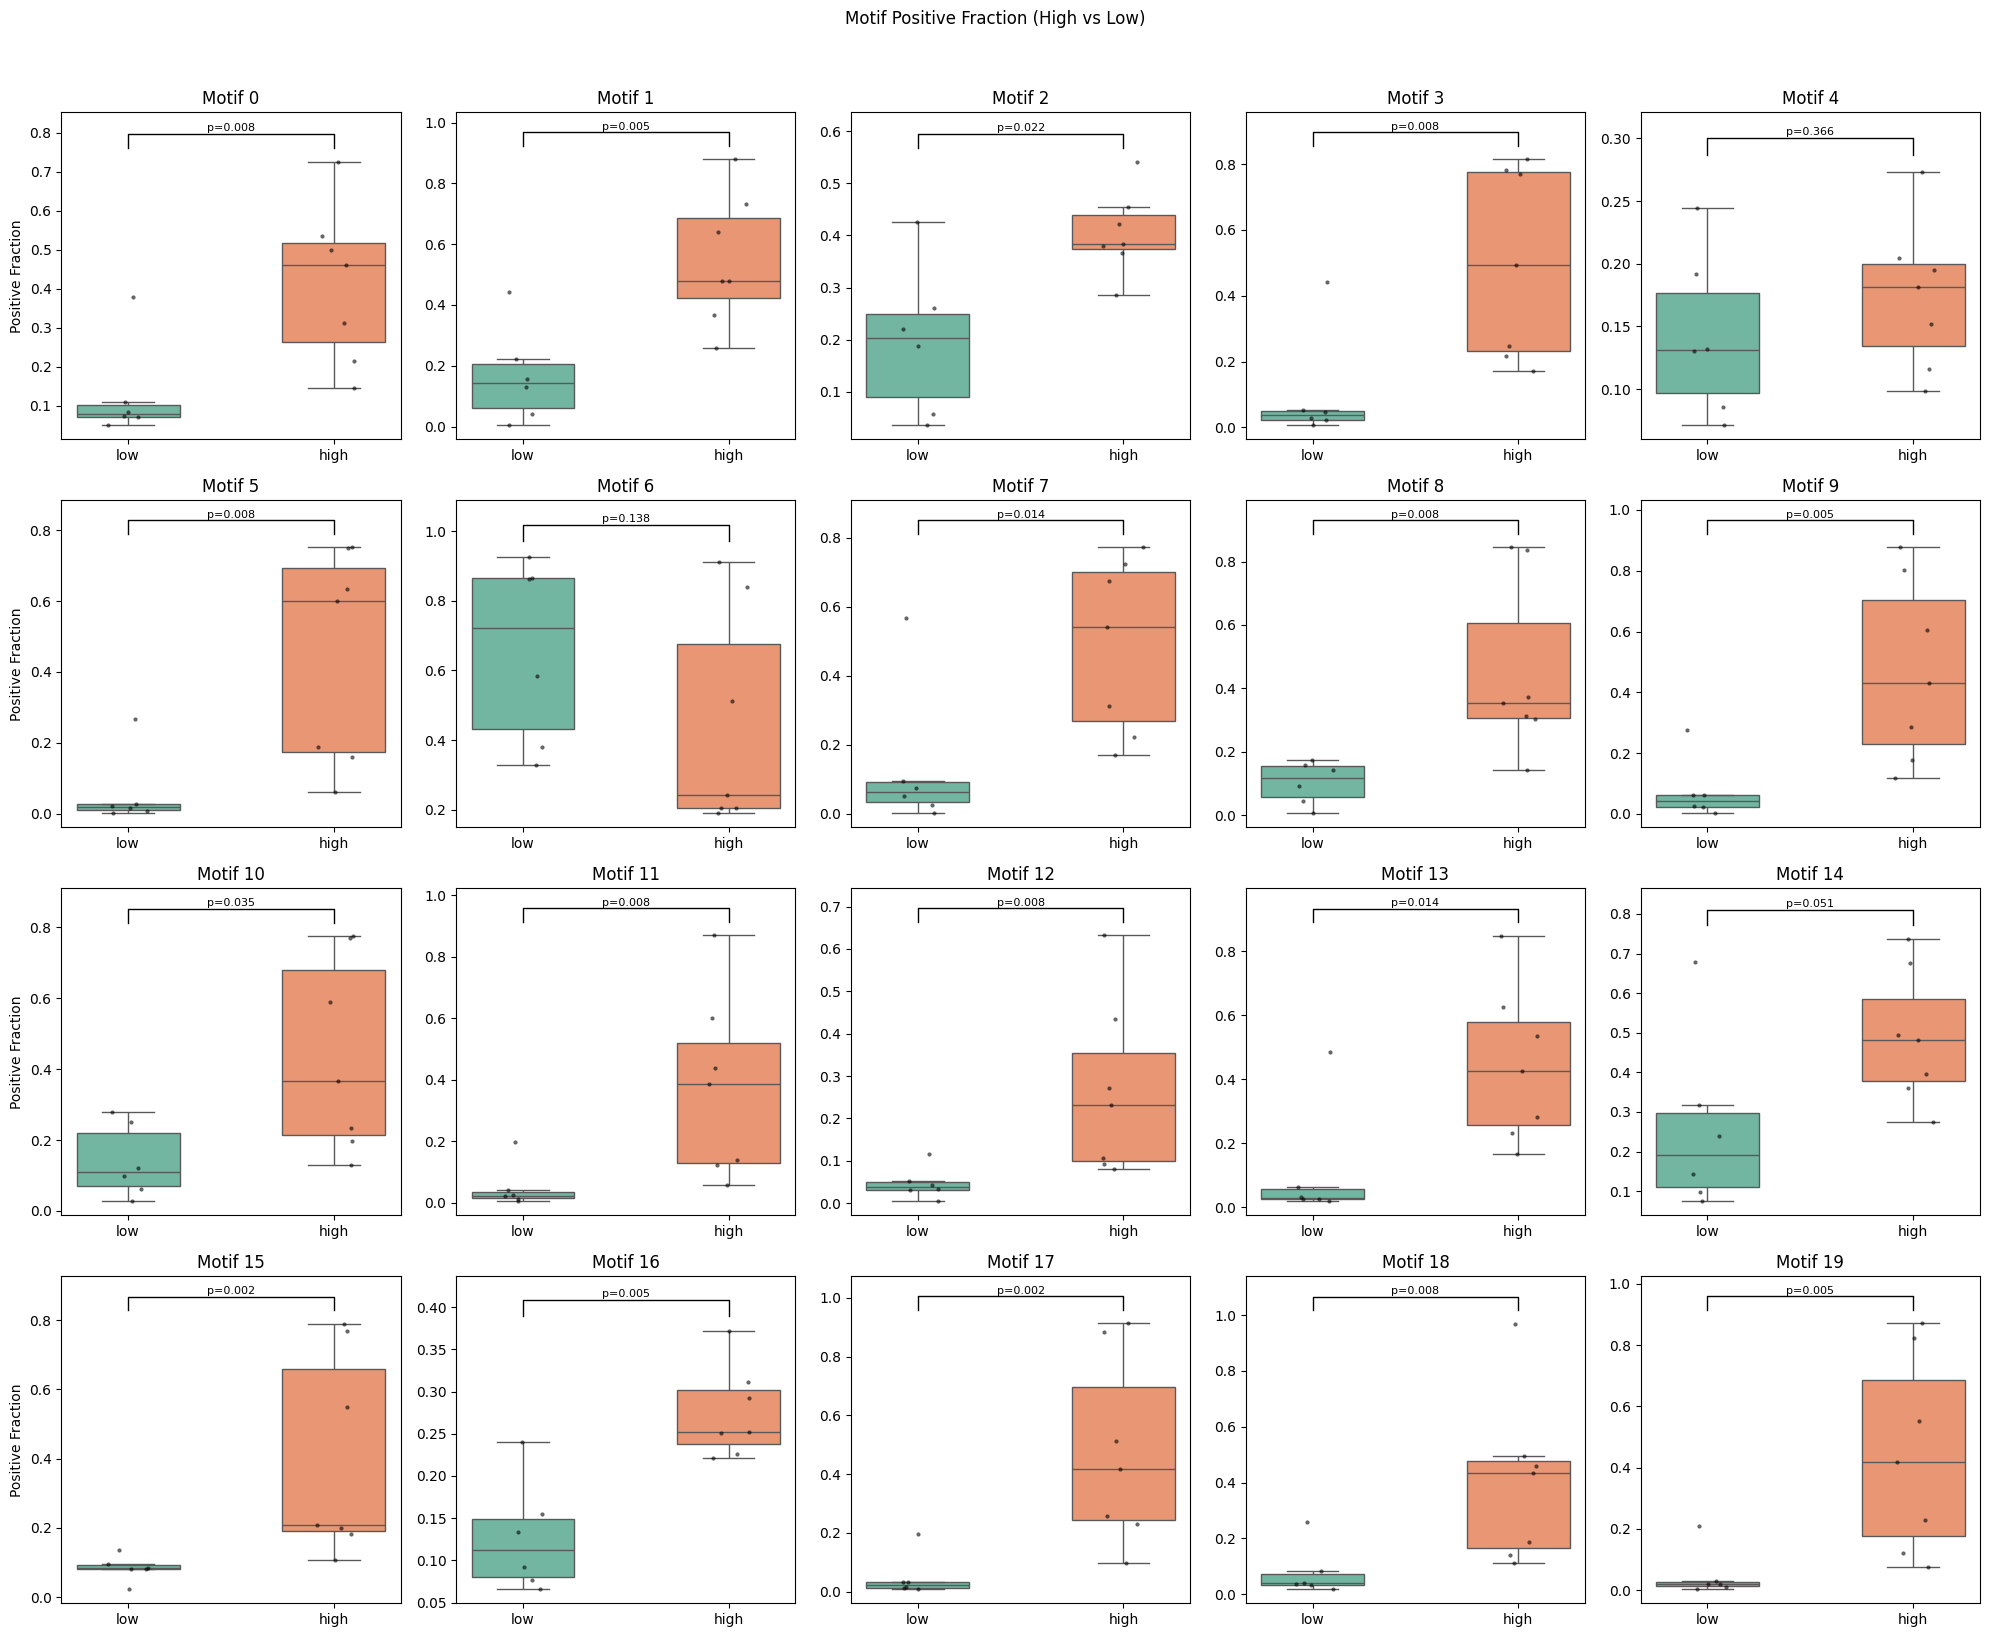

In [20]:
# multiple motifs
fig, axes, summary, p_values = plot_motif_fraction_by_grade(
    adata,
    motif_idx=list(range(20)),
    n_cols=5,
    # save_path=f'{results_dir}/all_motifs_grade.svg'
)

In [21]:
# check all p-values
for k, p in p_values.items():
    print(f"Motif {k}: p = {p:.3e}")

# select significant ones
sig_motifs = [k for k, p in p_values.items() if p < 0.05]
print(f"Significant motifs (p<0.05): {sig_motifs}")

Motif 0: p = 8.159e-03
Motif 1: p = 4.662e-03
Motif 2: p = 2.214e-02
Motif 3: p = 8.159e-03
Motif 4: p = 3.660e-01
Motif 5: p = 8.159e-03
Motif 6: p = 1.375e-01
Motif 7: p = 1.399e-02
Motif 8: p = 8.159e-03
Motif 9: p = 4.662e-03
Motif 10: p = 3.497e-02
Motif 11: p = 8.159e-03
Motif 12: p = 8.159e-03
Motif 13: p = 1.399e-02
Motif 14: p = 5.128e-02
Motif 15: p = 2.331e-03
Motif 16: p = 4.662e-03
Motif 17: p = 2.331e-03
Motif 18: p = 8.159e-03
Motif 19: p = 4.662e-03
Significant motifs (p<0.05): [0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]


# 6. Downstream Impact

In [ ]:
results = al.load_patch_lri_results(results_dir)
cell_loadings = np.load(f"{results_dir}/single_cell_20/cell_loadings.npy")

In [ ]:
# Verify alignment
assert cell_loadings.shape[0] == adata.shape[0], (
    f"Mismatch: cell_loadings has {cell_loadings.shape[0]} cells, "
    f"adata has {adata.shape[0]} cells"
)

In [ ]:
glm_results = al.run_poisson_glm_analysis(
    cell_loadings=cell_loadings,
    adata=adata,
    lri_column_names=results["column_name"],
    output_dir=f"{results_dir}/impact",
)

In [ ]:
# With Spearman pre-filtering (faster)
glm_results = al.run_poisson_glm_analysis(
    cell_loadings=cell_loadings,
    adata=adata,
    lri_column_names=results["column_name"],
    prefilter_spearman=True,
    spearman_pval_threshold=0.001,  # Only test genes with Spearman p < 0.001
    output_dir=f"{results_dir}/impact",
)

In [ ]:
# if computed already, reload
glm_results = al.load_glm_results(f"{results_dir}/impact")

In [ ]:
# First time: compute and optionally save
cell_types, genes, exclusion_mask = al.compute_exclusion_mask(
    adata,
    marker_lfc=1.0,
    marker_pvalue=1e-5,
    marker_subsample=50000,
    output_dir=f"{results_dir}/markers",  # Save for reuse
)
print(f"Computed exclusion mask for {len(cell_types)} cell types, {len(genes)} genes")

In [ ]:
cell_types, genes, exclusion_mask = al.load_exclusion_mask(
    f"{results_dir}/markers/exclusion_matrix.csv"
)

In [ ]:
# ========== Step 2: Volcano Plots ==========
print("\n2. Creating volcano plots...")
al.glm_volcano(
    adata=adata,
    de_results=glm_results,
    cell_types=cell_types,
    all_genes=genes,
    exclusion_mask=exclusion_mask,
    fdr_threshold=0.05,
    lfc_threshold=0.2,
    output_dir=f"{results_dir}/impact",
)

# ========== Step 3: Forest Plots ==========
print("\n3. Creating forest plots...")
al.glm_forest(
    adata=adata,
    de_results=glm_results,
    cell_types=cell_types,
    all_genes=genes,
    exclusion_mask=exclusion_mask,
    output_dir=f"{results_dir}/impact",  # Required when motif_id=None
)
print("\nAll analyses complete.")